In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("protein.csv")

df.head()

,RMSD,F1,F2,F3,F4,F5,F6,F7,F8,F9
0,17.284,13558.30,4305.35,0.31754,162.1730,1.872791e+06,215.3590,4287.87,102,27.0302
1,6.021,6191.96,1623.16,0.26213,53.3894,8.034467e+05,87.2024,3328.91,39,38.5468
2,9.275,7725.98,1726.28,0.22343,67.2887,1.075648e+06,81.7913,2981.04,29,38.8119
3,15.851,8424.58,2368.25,0.28111,67.8325,1.210472e+06,109.4390,3248.22,70,39.0651
4,7.962,7460.84,1736.94,0.23280,52.4123,1.021020e+06,94.5234,2814.42,41,39.9147


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45730 entries, 0 to 45729
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RMSD    45730 non-null  float64
 1   F1      45730 non-null  float64
 2   F2      45730 non-null  float64
 3   F3      45730 non-null  float64
 4   F4      45730 non-null  float64
 5   F5      45730 non-null  float64
 6   F6      45730 non-null  float64
 7   F7      45730 non-null  float64
 8   F8      45730 non-null  int64  
 9   F9      45730 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 3.5 MB


In [4]:
df.shape

(45730, 10)

In [5]:
df.describe()

,RMSD,F1,F2,F3,F4,F5,F6,F7,F8,F9
count,45730.000000,45730.000000,45730.000000,45730.000000,45730.000000,4.573000e+04,45730.000000,45730.000000,45730.000000,45730.000000
mean,7.748528,9871.596995,3017.367175,0.302392,103.492433,1.368299e+06,145.638061,3989.755990,69.975071,34.523664
std,6.118312,4058.138034,1464.324663,0.062886,55.424985,5.640367e+05,69.999230,1993.574575,56.493443,5.979755
min,0.000000,2392.050000,403.500000,0.092500,10.310100,3.194902e+05,31.970400,0.000000,0.000000,15.228000
25%,2.305000,6936.680000,1979.045000,0.258740,63.563900,9.535912e+05,94.757500,3165.322500,31.000000,30.424725
50%,5.030000,8898.805000,2668.155000,0.300150,87.740800,1.237219e+06,126.176000,3840.170000,54.000000,35.299300
75%,13.379000,12126.150000,3786.410000,0.342890,133.646750,1.690920e+06,181.468500,4644.192500,91.000000,38.870800
max,20.999000,40034.900000,15312.000000,0.577690,369.317000,5.472011e+06,598.408000,105948.170000,350.000000,55.300900


In [6]:
df.duplicated().sum()

np.int64(1711)

In [7]:
df.isnull().sum()

RMSD    0
F1      0
F2      0
F3      0
F4      0
F5      0
F6      0
F7      0
F8      0
F9      0
dtype: int64

## Filling Null Values

## Handling Outliers

In [8]:
cat_col=df.select_dtypes(include="object").columns
print(cat_col)

Index([], dtype='object')


In [9]:
num_cols=df.select_dtypes(include="number").columns
print(num_cols)

Index(['RMSD', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9'], dtype='object')


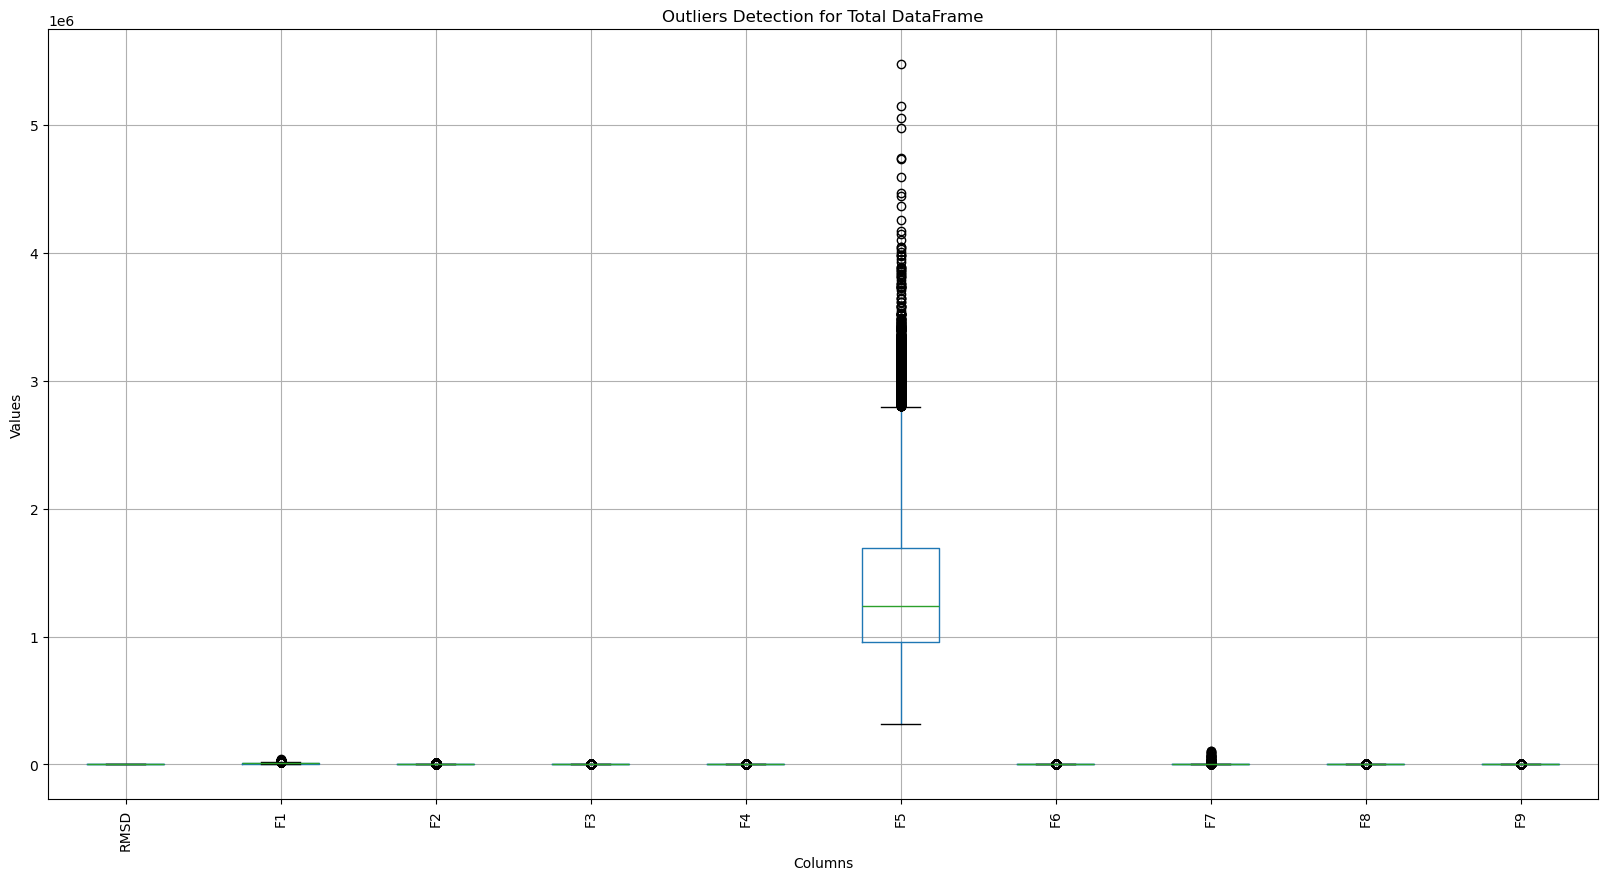

In [10]:
plt.figure(figsize=(20,10))

df.boxplot(rot=90)

plt.title("Outliers Detection for Total DataFrame")
plt.xlabel("Columns")
plt.ylabel("Values")

plt.show()

In [11]:
# Select numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping outliers
    df[col] = np.where(df[col] < lower_bound,
                       lower_bound,
                       df[col])

    df[col] = np.where(df[col] > upper_bound,
                       upper_bound,
                       df[col])

print("Outliers treated successfully")

Outliers treated successfully


In [13]:
df.shape

(45730, 10)

In [14]:
y = df['RMSD']
x = df.drop('RMSD', axis=1)

In [15]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45730 entries, 0 to 45729
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F1      45730 non-null  float64
 1   F2      45730 non-null  float64
 2   F3      45730 non-null  float64
 3   F4      45730 non-null  float64
 4   F5      45730 non-null  float64
 5   F6      45730 non-null  float64
 6   F7      45730 non-null  float64
 7   F8      45730 non-null  float64
 8   F9      45730 non-null  float64
dtypes: float64(9)
memory usage: 3.1 MB


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import pandas as pd

ct = ColumnTransformer(
    transformers=[
        ("sc", StandardScaler(), [0,1,2,3,4,5,6,7,8])
    ]
)

x_transformed = ct.fit_transform(x)

x_transformed = pd.DataFrame(x_transformed, columns=x.columns)

x_transformed

,F1,F2,F3,F4,F5,F6,F7,F8,F9
0,0.969485,0.954368,0.245857,1.137439,0.946562,1.065801,0.344573,0.729115,-1.254439
1,-0.935559,-0.992270,-0.643459,-0.936959,-1.030621,-0.860985,-0.531993,-0.586847,0.673161
2,-0.538838,-0.917429,-1.264585,-0.671913,-0.527330,-0.942339,-0.849974,-0.795730,0.717533
3,-0.358170,-0.451510,-0.338835,-0.661543,-0.278044,-0.526666,-0.605750,0.060690,0.759912
4,-0.607408,-0.909693,-1.114199,-0.955591,-0.628335,-0.750917,-1.002278,-0.545071,0.902115
...,...,...,...,...,...,...,...,...,...
45725,-0.458373,-0.154361,0.696213,-0.728160,-0.471585,-0.476947,-0.481444,0.353126,0.381392
45726,-0.473466,-0.349671,0.195461,-0.508363,-0.451379,-0.634344,0.058146,-0.273523,0.254755
45727,-0.538665,-0.363453,0.320649,-0.601327,-0.525642,-0.613281,-0.567139,-0.440629,0.493232
45728,-0.240669,0.047474,0.673101,-0.161955,-0.219258,-0.440127,-0.447093,-0.545071,0.180691


In [17]:
# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [18]:
x_train_transform=ct.fit_transform(x_train)
x_tarin_transorm=pd.DataFrame(x_train_transform)

In [19]:
x_test_transform=ct.transform(x_test)
x_test_transform=pd.DataFrame(x_test_transform)

In [20]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train_transform,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred=model.predict(x_test_transform)

In [22]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.28435901662386875


In [23]:
# Ridge Regression
from sklearn.linear_model import Ridge

# Lasso Regression
from sklearn.linear_model import Lasso

In [24]:
ls=Lasso()

In [25]:
ls.fit(x_train_transform,y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [26]:
y_pred=ls.predict(x_test_transform)

In [27]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.11438373789643586


In [28]:
ridge = Ridge()

In [29]:
ridge.fit(x_train_transform,y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [30]:
y_pred_ridge = ridge.predict(x_test_transform)

In [31]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.11438373789643586


In [32]:
print("Train Score :", model.score(x_train_transform, y_train))
print("Test Score :", model.score(x_test_transform, y_test))

Train Score : 0.2951195772992641
Test Score : 0.28435901662386875


In [33]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()

model.fit(x_train_transform, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [34]:
y_pred = model.predict(x_test_transform)

In [35]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.3316731258925053
